# Terminal rendering with meshio++ (R)

R counterpart of [`../python/31_terminal_rendering.ipynb`](../python/31_terminal_rendering.ipynb): meshio++'s own **software rasterizer** draws a mesh with no display, GPU or plotting package, called through the `meshioplusplus` R package (`mio_render`, `mio_render_png`, `mio_render_text`, `mio_write_snapshot`). Unlike the SVG route of the other R notebooks, this one reaches **every** option of the rasterizer through the C API, so the pictures below are coloured by data, with contour lines, arrows, streamlines and a cut-away. See [`doc/tui.md`](../../doc/tui.md) and [`doc/r.md`](../../doc/r.md).

`mio_frame_image` in [`mio_notebook.R`](mio_notebook.R) encodes a frame as a PNG and hands it to `IRdisplay`, which IRkernel shows inline.

In [1]:
source("mio_notebook.R")

mesh <- mio_read("example.vtu")
cat("points:", mio_num_points(mesh), ", blocks:", paste(mio_cell_block_types(mesh), collapse = ", "), "\n")

points: 52282 , blocks: triangle, tetra 


## Some fields to draw

The bracket carries no solution, so make some from its geometry: a scalar `h`, a displacement `disp` and a rotation velocity `vel` about the part's vertical axis. A vector point array is a `3 x N` matrix.

In [2]:
P <- mio_points(mesh)
mid <- rowMeans(P)
lo <- apply(P, 1, min)
hi <- apply(P, 1, max)
mio_add_point_data(mesh, "h", P[1, ] + 0.5 * P[2, ])
mio_add_point_data(mesh, "disp", rbind(0, 0, 0.15 * (P[1, ] - lo[1]) / (hi[1] - lo[1])))
mio_add_point_data(mesh, "vel", rbind(-(P[2, ] - mid[2]), P[1, ] - mid[1], 0))
cat("point data:", paste(mio_point_data_names(mesh), collapse = ", "), "\n")

point data: disp, h, vel 


## A frame

`mio_frame_image` takes the options of `mio_render` as arguments: a named `view`, `edges = "feature"` for the sharp edges, `shading = "smooth"`. A volume is drawn through its boundary skin.

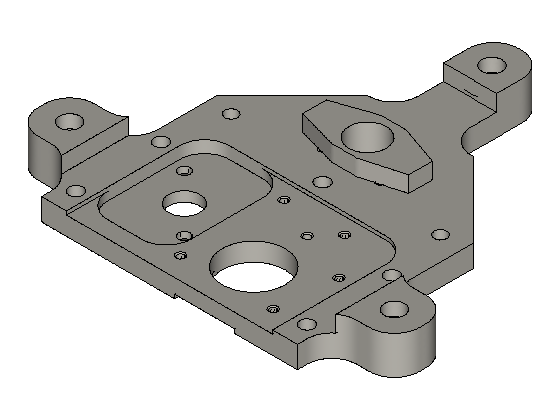

In [3]:
mio_frame_image(mesh, edges = "feature", shading = "smooth", background = mio_rgba(255, 255, 255))

## Colouring by data

`color_by` takes point data first, then cell data. `mio_render` returns a `mio_frame` with the pixels, the cell id of every pixel and the notes a terminal rendering prints under its picture.

range: -4.181875 -0.003180384 
h: -4.18187 .. -0.00318038 (plasma)
ticks: -4, -3, -2, -1


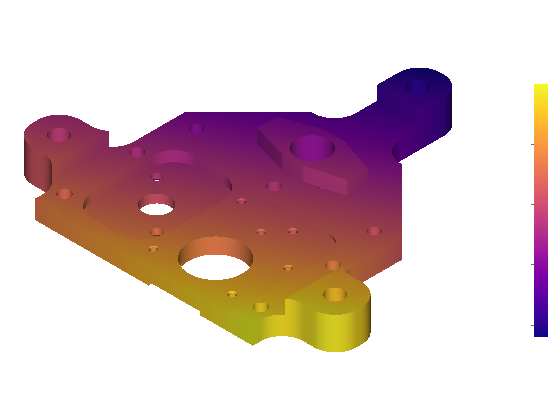

In [4]:
f <- mio_render(mesh, width = 560L, height = 420L, color_by = "h", colorbar = TRUE, cmap = "plasma")
cat("range:", f$range, "\n")
cat(f$notes, sep = "\n")
mio_frame_image(mesh, color_by = "h", colorbar = TRUE, cmap = "plasma", shading = "smooth")

## Field options

Contour lines of a point array, arrows for a vector array, and a warp by a displacement that also draws the undeformed outline.

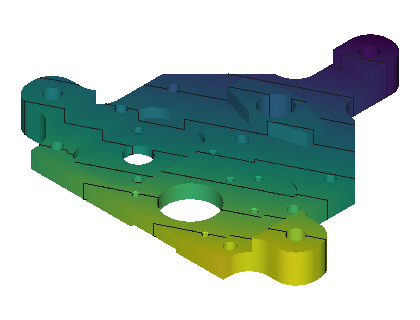

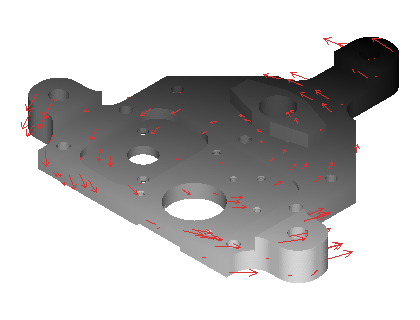

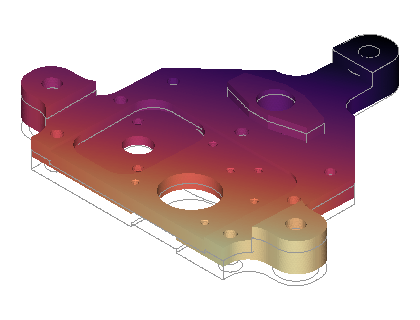

In [5]:
mio_frame_image(mesh, color_by = "h", isolines = 8L, cmap = "viridis", width = 420L, height = 320L)
mio_frame_image(mesh, color_by = "h", vectors = "vel", vector_count = 300L, cmap = "grey", width = 420L, height = 320L)
mio_frame_image(mesh, color_by = "h", warp = "disp", warp_outline = TRUE, cmap = "magma", width = 420L, height = 320L)

## Streamlines

Added in v16.37.0. `streamlines = "vel"` follows a vector point array over the mesh's own cells: on the skin (a surface) the lines stay on it, and in the volume they run inside it, so a `cutaway` shows them. `cutaway` is a point and the normal of the side kept; `-z` through the middle keeps the lower half and tints the inside.

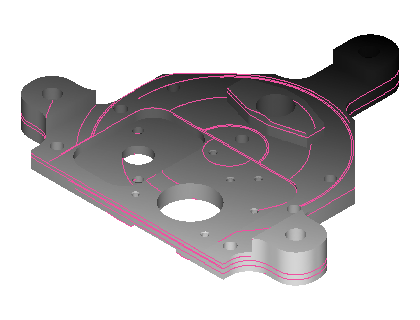

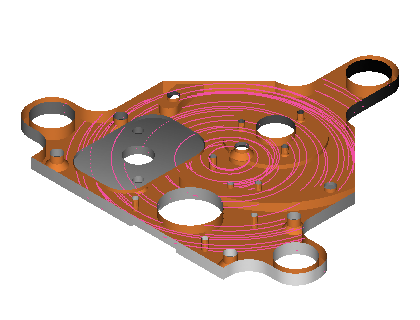

In [6]:
skin <- mio_extract_skin(mesh, linearize = TRUE)
mio_frame_image(skin, color_by = "h", cmap = "grey", streamlines = "vel", stream_seeds = 60L,
                stream_length = 0.4, shading = "smooth", width = 420L, height = 320L)
mio_frame_image(mesh, color_by = "h", cmap = "grey", streamlines = "vel", stream_seeds = 120L,
                stream_length = 0.4, shading = "smooth", cutaway = c(mid, 0, 0, -1),
                width = 420L, height = 320L)

## The terminal form

`mio_render_text` returns what a terminal prints: block glyphs with colour escapes, or glyphs only with `color_depth = "mono"`.

In [7]:
cat(mio_render_text(mesh, cols = 64L, rows = 18L, encoding = "braille", color_depth = "mono", edges = "feature"))

⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣤⣶⢟⣛⡻⣶⣤⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢶⣭⡛⠬⣭⣥⠿⡋⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣀⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣤⣤⣤⣤⣤⣤⣤⣤⣤⡤⢀⠤⠤⣤⣀⣀⠀⠀⣀⣠⣴⣾⣷⣦⣉⠓⡎⣴⣮⡇⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⣶⣿⠫⣭⡍⢻⣷⡦⢄⠀⠀⠀⠀⢀⣠⣴⣿⣿⣅⣒⣽⣿⣿⣿⣿⣿⠑⢾⣿⣿⡿⠶⡪⠭⢙⠿⣿⣿⣿⣿⣿⣿⡿⢛⣠⣿⡿⠃⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢈⡛⢷⣶⠾⣛⢥⡶⣛⣤⣤⡄⠬⠹⠟⣛⣛⣛⡻⢿⣿⣿⣿⣿⣿⣿⣄⠀⠙⠏⢰⣿⣿⣿⠇⣱⣎⠻⣿⣿⣿⡏⢸⠿⠛⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢸⣿⠀⣴⠎⣢⣵⣾⣿⣿⠿⢛⡭⢖⠫⢭⣭⣭⣭⡓⠮⣙⠻⣿⣿⣿⣿⣧⣄⠳⣦⣔⣒⠶⢾⣿⣿⡷⠘⣿⣿⣷⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠘⠻⠀⠶⠿⢿⣿⠿⣋⠥⢚⣭⣾⣷⣥⣴⣿⣿⣿⣿⣷⣮⣄⢠⡙⠻⢿⠫⠭⣻⣶⣭⣛⠛⠳⣶⢰⠾⣃⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⣐⡺⠮⠍⣈⠀⣪⣵⣾⣿⣿⡏⠖⠒⠒⠎⣿⣿⣿⡿⢛⣥⣎⠉⣷⣦⣌⡛⠿⣿⣿⣿⣿⣿⣶⣶⣾⣿⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠻⢿⣦⣛⠿⣧⣝⡻⢿⣿⣿⣷⣦⣤⣤⡶⠟⣫⣵⣾⣿⣿⣿⣿⣿⣿⣿⣿⣶⣄⡉⠻⢿⣿⣿⣿⣿⣿⠿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠛⠿⣦⣍⡻⢶⣬⣛⣛⣃⣀⣤⣶⣿⠿⣛⣛⣛⠛⢛⠿⣿⣀⣼⣿⣧⣤⣿⣷⣦⣈⢻⣿⣿⣧⣭⣼⡿⠃⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠻⢷⣬⣙⠿⣧⣤⣿⣿⠁⠿⠛⠛⠛⠉⠑⠒⠈⣿⣿⣿⣿⣿⣿⣿⠟⠋⢼⣿⣿⠟⣫⣵⣾⠇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠛⠿⣮⣝⡻⢿⣦⣀⠀⠀⠀⠀⠀⣀⣴⣿⣿⣿⡄⠜⣉⣴⠦⣉⣥⡉⠶⡿⠛⠉⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠙⠲⢬⣛⠿⣿⣿⡟⠛⣿⣿⠿⢛⣡⡶⢟⣩⣴⡟⣫⣭⢻⣷⣆⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠛⣦⣝⡻⠖⣉⣄⠤⢉⠿⠰⣶⣭⡛⠷⠶⠶⠾⢛⡁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀

## Files

`mio_write_snapshot` picks the form from the extension (`.png`, `.txt`, `.ansi`, `.html`, or a `.cast` orbit for asciinema).

In [8]:
dir <- tempfile("snapshots"); dir.create(dir)
for (name in c("part.png", "part.txt", "part.html", "part.cast")) {
  path <- file.path(dir, name)
  mio_write_snapshot(path, mesh, width = 320L, height = 240L, cols = 60L, rows = 16L,
                     streamlines = "vel", stream_seeds = 30L, cast_frames = 6L)
  cat(formatC(name, width = -10), file.size(path), "bytes\n")
}
cat("PNG signature:", identical(readBin(file.path(dir, "part.png"), "raw", 8),
                                as.raw(c(0x89, 0x50, 0x4e, 0x47, 0x0d, 0x0a, 0x1a, 0x0a))), "\n")

part.png   307528 bytes
part.txt   1675 bytes
part.html  12449 bytes
part.cast  49157 bytes
PNG signature: TRUE 
